In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout

In [2]:
tf.__version__

'2.10.1'

In [3]:
#configuring gpu memory usage

gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    try:
        # Set a memory limit for the first GPU (assuming at least one GPU is available)
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=4096)])  # Limit to 4GB
        
        # After setting the configuration, list logical GPUs to verify the configuration
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        
        # Print information about the available GPUs and logical GPUs
        print(len(gpus), "Physical GPU(s) available,", len(logical_gpus), "Logical GPU(s) configured.")
        
    except RuntimeError as e:
        # Print any runtime error that occurs during configuration
        print("Error:", e)
else:
    print("No GPU(s) available. TensorFlow cannot use GPU acceleration.")

    

1 Physical GPU(s) available, 1 Logical GPU(s) configured.


In [4]:
# helper function to plot model history
def plot_training_history(history):
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [5]:
df = pd.read_parquet("dialog_embeddings.parquet",engine='pyarrow')

In [6]:
df

,dialog,bert,word2vec,tfidf
0,I should have known that you would be here...P...,"[0.11776354, -0.03167579, -0.024686715, -0.134...","[-0.10712552, 0.3143555, -0.039015435, 0.02018...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,"Good evening, Professor Dumbledore. Are the ru...","[0.4448558, 0.028105292, 0.37416452, -0.036972...","[-0.0015624807, 0.26561326, 0.021989755, -0.05...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,"I'm afraid so, Professor. The good, and the bad.","[0.00507164, 0.2951181, 0.31627423, -0.2078724...","[-0.033801053, 0.25057238, 0.06684917, 0.02926...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,Do you think it wise to trust Hagrid with some...,"[-0.2072944, 0.03967307, -0.55406237, -0.17534...","[-0.0012513548, 0.20426989, 0.014577895, -0.07...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,"Ah, Professor, I would trust Hagrid with my life.","[0.08848735, 0.51767176, 0.30891284, -0.155208...","[-0.123381026, 0.30085436, 0.016374543, -0.000...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...
4417,"Well, it wasn't boring, was it?","[0.12381233, -0.07896332, -0.11148949, 0.22739...","[-0.041103512, 0.33554858, 0.041814156, -0.148...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4418,Don't forget to give Professor Longbottom our ...,"[0.42352563, 0.007568689, -0.089991786, -0.222...","[-0.052776705, 0.19843607, 0.11255942, -0.0553...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4419,There's nothing scary about thestrals. They're...,"[0.2444465, 0.012391215, 0.3874211, 0.27899718...","[0.03917932, 0.19301426, -0.0025303557, -0.100...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4420,Albus Severus Potter. You were named after two...,"[0.009933477, -0.10251515, -0.114123456, 0.051...","[0.01673613, 0.29748204, -0.061036784, -0.0642...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [7]:
def BERT_data_prep(sentence_list, bert_embeddings, label_encoder=None):
    if label_encoder is None:
        label_encoder = LabelEncoder()

    X = []  # this will store input sequences
    targets = [] # this will  store next word for each input sequence 
    

    # generating input-target pairs
    for emb_index, sentence in enumerate(sentence_list):
        words = sentence.split()
        for i in range(1, len(words)):
            input_seq = ' '.join(words[:i])  # all words up to but not including the target word
            target_word = words[i]  # corresponding next word for input_seq
            
            # appending the corresponding BERT embedding (handling repetition)
            X.append(bert_embeddings[emb_index])  # appending the embedding directly
            targets.append(target_word)

    # converting X to a NumPy array and reshaping it for LSTM input (num_samples, 1, embedding_size)
    X = np.array(X)  
    X = X.reshape(X.shape[0], 1, X.shape[1])  
    
    # encoding targets
    y = label_encoder.fit_transform(targets)  # Convert words to integers
    y = to_categorical(y)  # One-hot encoding the labels

    return X, y, targets, label_encoder


In [8]:
def BERT_LSTM_model(X,y):

  model = Sequential()
  model.add(LSTM(150, input_shape=(X.shape[1], X.shape[2]), return_sequences=True))  # First LSTM layer
  model.add(Dropout(0.2))  # Dropout layer to reduce overfitting
  model.add(LSTM(100))  # Second LSTM layer
  model.add(Dropout(0.2))  # Another Dropout layer
  model.add(Dense(y.shape[1], activation='softmax'))

  model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

  return model

In [9]:
dialogs = list(df['dialog'])
bert = list(df['bert'])

In [10]:

bert_X, bert_y, bert_targets, bert_encoder = BERT_data_prep(sentence_list=dialogs,bert_embeddings=bert)

In [11]:

split_ratio = 0.8
split_index = int(len(bert_X) * split_ratio)

X_train, X_val = bert_X[:split_index], bert_X[split_index:]
y_train, y_val = bert_y[:split_index],bert_y[split_index:]


In [12]:
bert_model = BERT_LSTM_model(bert_X,bert_y)

In [13]:
# training the bert model
bert_model_history = bert_model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_val,y_val), verbose=1)


Epoch 1/100
1510/1510 [==============================] - 11s 6ms/step - loss: 7.5333 - accuracy: 0.0299 - val_loss: 7.4146 - val_accuracy: 0.0305
Epoch 2/100
1510/1510 [==============================] - 8s 5ms/step - loss: 7.2594 - accuracy: 0.0326 - val_loss: 7.4969 - val_accuracy: 0.0388
Epoch 3/100
1510/1510 [==============================] - 8s 5ms/step - loss: 7.1852 - accuracy: 0.0376 - val_loss: 7.5328 - val_accuracy: 0.0436
Epoch 4/100
1510/1510 [==============================] - 8s 5ms/step - loss: 7.0878 - accuracy: 0.0435 - val_loss: 7.5548 - val_accuracy: 0.0503
Epoch 5/100
1510/1510 [==============================] - 8s 5ms/step - loss: 6.9664 - accuracy: 0.0470 - val_loss: 7.6020 - val_accuracy: 0.0543
Epoch 6/100
1510/1510 [==============================] - 8s 5ms/step - loss: 6.8402 - accuracy: 0.0501 - val_loss: 7.6559 - val_accuracy: 0.0537
Epoch 7/100
1510/1510 [==============================] - 7s 5ms/step - loss: 6.7169 - accuracy: 0.0520 - val_loss: 7.6774 - val_a

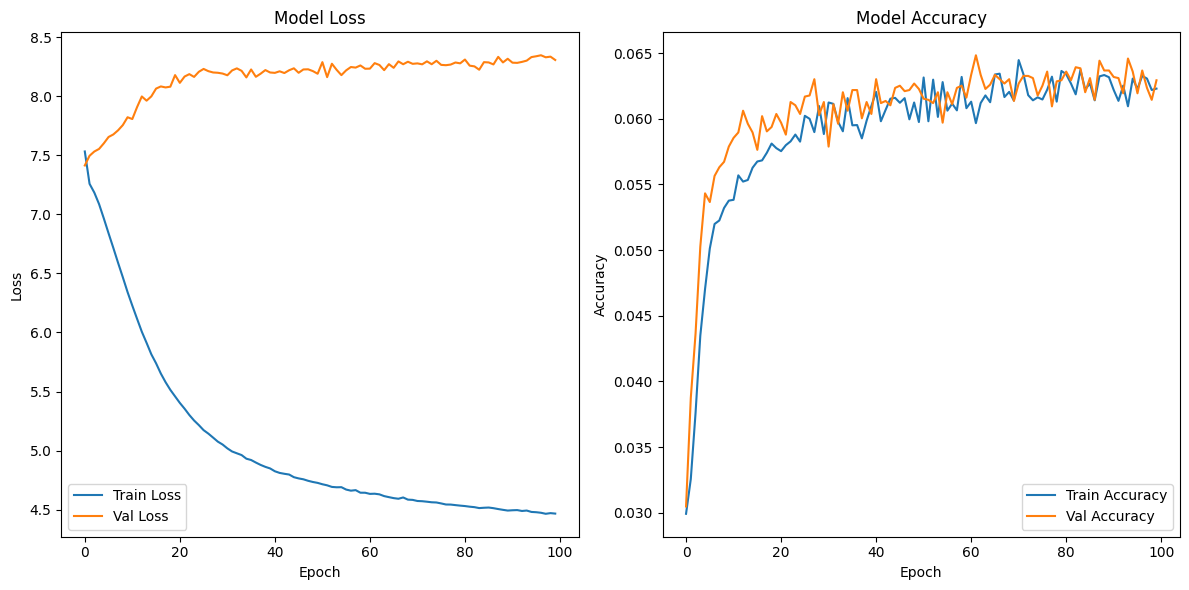

In [14]:
plot_training_history(bert_model_history)

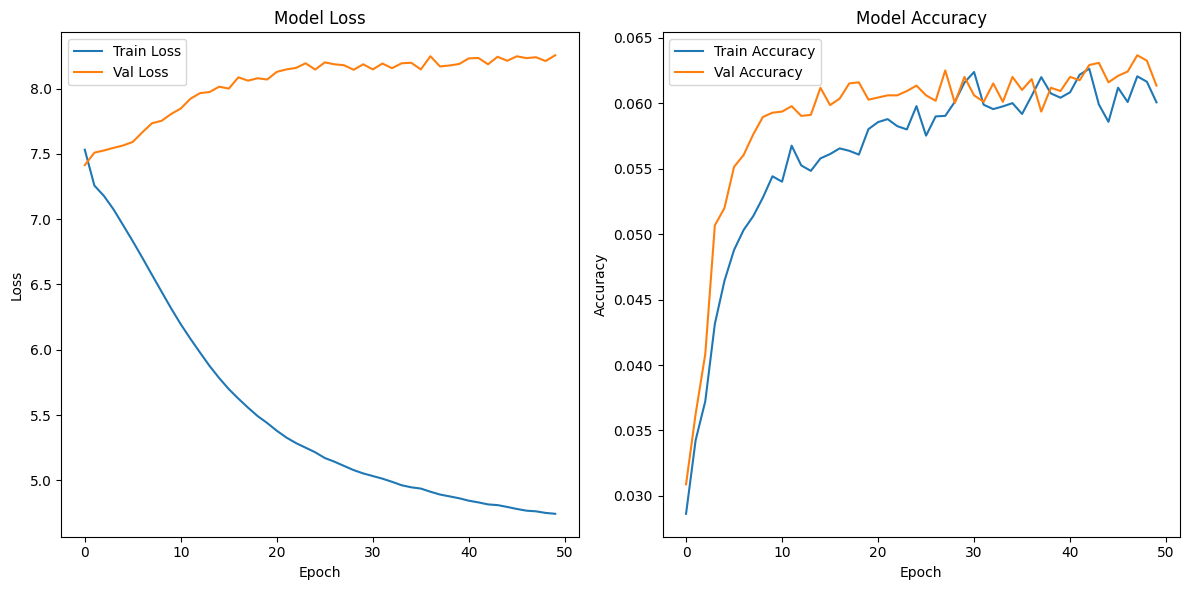

In [16]:
plot_training_history(bert_model_history)